In [1]:
import torch
import numpy as np
import os
from tqdm import tqdm
from utils._resnet import resnet18_8
import shutil


In [2]:
# Split saved ResNet 18_8 model and add avgpool and fc layers to both sides

In [3]:
model = resnet18_8()
# model_path="./saved_models/resnet18_8_b64_lr0.0001_noiseless/checkpoint.pt"
model_path="./saved_models/resnet18_8_b64_lr0.0001_1000_noiseless/checkpoint.pt"

model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [4]:
# model from the beginning layer 1 cut up to, up to there require grad False, (freeze), then avgpool, fc (require grad True) add
class Flatten(torch.nn.Module):
    def forward(self, x):
        x = torch.flatten(x, 1)
        return x
    
cutted_model = torch.nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    # make pooling in length dimension
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 32)),
    # making pooling for 
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
    # make name,
    Flatten(),
    torch.nn.Linear(in_features=model.layer1[-1].conv2.out_channels, out_features=4)
)
# add name to last layer
cutted_model[-1].name = "cutted_model_fc"
# require grad False
for layer in cutted_model[:-1]:
    for param in layer.parameters():
        if hasattr(layer, 'name') and layer.name == "cutted_model_fc":
            param.requires_grad = True
        else:
            param.requires_grad = False


In [5]:
# print cutted model info, what is trainable and what are freeze, module-wise
print("Cutted model:")
for name, param in cutted_model.named_parameters():
    if param.requires_grad:
        print(f"{name} is trainable")
    else:
        print(f"{name} is frozen")

Cutted model:
0.weight is frozen
1.weight is frozen
1.bias is frozen
4.0.conv1.weight is frozen
4.0.bn1.weight is frozen
4.0.bn1.bias is frozen
4.0.conv2.weight is frozen
4.0.bn2.weight is frozen
4.0.bn2.bias is frozen
4.1.conv1.weight is frozen
4.1.bn1.weight is frozen
4.1.bn1.bias is frozen
4.1.conv2.weight is frozen
4.1.bn2.weight is frozen
4.1.bn2.bias is frozen
8.weight is trainable
8.bias is trainable


In [6]:
import os
import numpy as np
import torch
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from utils._preprocessing import _preprocessing_dataset, _get_dataloader
from utils._train import train
import shutil

def createFolder(directory):
    try:
        if not os.path.exists(directory):
            os.makedirs(directory)
    except OSError:
        print ('Error: Creating directory. ' +  directory)



# --- Balancing Helper ---
def balance_dataset(dataset: TensorDataset) -> TensorDataset:
    """
    Perform undersampling according to minimum sample count per class, then shuffle and return.
    """
    data, labels = dataset.tensors
    counts = Counter(labels.numpy())
    min_count = min(counts.values())
    idx_list = []
    for lbl in sorted(counts):
        idxs = np.where(labels.numpy() == lbl)[0]
        chosen = np.random.choice(idxs, min_count, replace=False)
        idx_list.extend(chosen.tolist())
    idx_tensor = torch.tensor(idx_list, dtype=torch.long)
    idx_tensor = idx_tensor[torch.randperm(len(idx_tensor))]
    return TensorDataset(data[idx_tensor], labels[idx_tensor])

# --- DataLoader Preparation ---
def prepare_dataloader(
    ds_tuple: tuple,
    label_map: dict,
    batch_size: int,
    balance: bool = True,
    subset_ratio: float = 1.0,
    shuffle: bool = True,
) -> DataLoader:
    """
    1) ds_tuple: (X_array, y_array)
    2) Scaling and dimension processing (_preprocessing_dataset)
    3) Batch decomposition (_get_dataloader)
    4) Label mapping → balancing → subset application
    """
    # 1-3
    X, y = _preprocessing_dataset(ds_tuple, scale="minmax")
    dl = _get_dataloader(X, y, batch_size=batch_size, shuffle=shuffle)
    data, labels = dl.dataset.tensors

    # 4a) Mapping
    mapped = torch.tensor(
        [label_map[int(lbl.item())] for lbl in labels],
        dtype=torch.long
    )
    ds_mapped = TensorDataset(data, mapped)
    
    # 4b) Balancing
    if balance:
        ds_mapped = balance_dataset(ds_mapped)
    
    # 4c) Subset (apply subset_ratio)
    if subset_ratio < 1.0:
        total = len(ds_mapped)
        N = int(total * subset_ratio)
        perm = torch.randperm(total)[:N]
        d, l = ds_mapped.tensors
        ds_mapped = TensorDataset(d[perm], l[perm])

    return DataLoader(ds_mapped, batch_size=batch_size, shuffle=shuffle)

In [ ]:
# --- Configuration ---
batch_size = 1024
lr = 1e-4
train_dir_size = 5
subset_ratio = 1

block = 1


# Dictionary mapping original labels to cluster labels
label_map_dict = {
    0: 2,  # SubATTM -> cluster 2
    1: 2,  # SubCTRW -> cluster 2
    2: 0,  # SubFBM  -> cluster 0
    3: 3,  # SubSBM  -> cluster 3
    4: 1,  # SupFBM  -> cluster 1
    5: 1,  # SupLW   -> cluster 1
    6: 3,  # SupSBM  -> cluster 3
    7: 3   # BM      -> cluster 3
}

In [8]:
# Model saving and checkpoint path configuration
model_save_dir = f"./analysis_results/statistical_relevance_block/cutted_model/resnet18_8_b{batch_size}_lr{lr}_1000_noiseless/"
ckpt_dir = f"./analysis_results/statistical_relevance_block/cutted_model/model_ckpt/{block}/"
for d in (model_save_dir, ckpt_dir):
    os.makedirs(d, exist_ok=True)

In [9]:
# make print output shape in model
def print_shapes(current_model, input_tensor):
    def forward_hook(module, input, output):
        print(f"{module.__class__.__name__} output shape: {output.shape}")

    hooks = []
    for layer in current_model:
        hooks.append(layer.register_forward_hook(forward_hook))

    current_model(input_tensor)

    for hook in hooks:
        hook.remove()

input_tensor = torch.randn(1, 2, 1, 1000)  #
print_shapes(cutted_model, input_tensor) 

Conv2d output shape: torch.Size([1, 64, 1, 500])
BatchNorm2d output shape: torch.Size([1, 64, 1, 500])
ReLU output shape: torch.Size([1, 64, 1, 500])
MaxPool2d output shape: torch.Size([1, 64, 1, 250])
Sequential output shape: torch.Size([1, 64, 1, 250])
AdaptiveAvgPool2d output shape: torch.Size([1, 64, 1, 32])
AdaptiveAvgPool2d output shape: torch.Size([1, 64, 1, 1])
Flatten output shape: torch.Size([1, 64])
Linear output shape: torch.Size([1, 4])


In [10]:
if os.path.exists(model_save_dir + f"block{block}_checkpoint.pt"):
    print(f"Load model from {model_save_dir + f'block{block}_checkpoint.pt'}")
    cutted_model.load_state_dict(torch.load(model_save_dir + f"/block{block}_checkpoint.pt"))

    # eval, classficiation check
    eval_arr = np.load("./dataset_noiseless/test_1000/0.npy", allow_pickle=True)
    eval_loader = prepare_dataloader(
        ds_tuple=(eval_arr[0], eval_arr[1]),
        batch_size=batch_size,
        label_map=label_map_dict,
        subset_ratio=subset_ratio,
    )

    # eval model
    cutted_model.eval()
    cutted_model.to("cuda" if torch.cuda.is_available() else "cpu")
    correct = 0
    total = 0
    ground_truth = []
    predictions = []
    with torch.no_grad():
        for data, labels in tqdm(eval_loader, desc="Evaluating model"):
            data = data.to("cuda" if torch.cuda.is_available() else "cpu")
            labels = labels.to("cuda" if torch.cuda.is_available() else "cpu")
            outputs = cutted_model(data)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            ground_truth.extend(labels.cpu().numpy())
            predictions.extend(predicted.cpu().numpy())
    accuracy = correct / total * 100
    print(f"Evaluation accuracy: {accuracy:.2f}%")
    print("Model evaluation complete.")
else:
    print(f"Train model and save checkpoint to {model_save_dir + f'/block{block}_checkpoint.pt'}")
    # --- Eval DataLoader ---
    eval_arr = np.load("./dataset_noiseless/eval_1000/0.npy", allow_pickle=True)
    eval_loader = prepare_dataloader(
        ds_tuple=(eval_arr[0], eval_arr[1]),
        batch_size=batch_size,
        label_map=label_map_dict,
        subset_ratio=subset_ratio,
    )
    print("Eval dataset label ratio:")
    eval_labels = eval_loader.dataset.tensors[1].numpy()
    for lbl, cnt in Counter(eval_labels).items():
        pct = cnt / len(eval_labels) * 100
        print(f"Label {lbl}: {cnt} samples ({pct:.2f}%)")

    # --- Train DataLoaders ---
    train_loaders = []
    for i in range(train_dir_size):
        arr = np.load(f"./dataset_noiseless/train_1000/{i}.npy", allow_pickle=True)
        loader = prepare_dataloader(
            ds_tuple=(arr[0], arr[1]),
            batch_size=batch_size,
            label_map=label_map_dict,
            subset_ratio=subset_ratio,
        )
        train_loaders.append(loader)

    # --- Training & Checkpoint ---
    train(
        cutted_model,
        num_epochs=100,
        train_dataloaders=train_loaders,
        eval_dataloader=eval_loader,
        save_path=ckpt_dir,
        lr=lr,
    )
    shutil.copy(
        os.path.join(ckpt_dir, "checkpoint.pt"),
        os.path.join(model_save_dir, f"block{block}_checkpoint.pt"),
    )

    print("Training complete. Model saved to:", model_save_dir + f"/block{block}_checkpoint.pt")

Load model from ./analysis_results/statistical_relevance_block/cutted_model/resnet18_8_b1024_lr0.0001_1000_noiseless/block1_checkpoint.pt


Evaluating model: 100%|██████████| 40/40 [00:01<00:00, 37.71it/s]

Evaluation accuracy: 89.44%
Model evaluation complete.


In [11]:
label_map_dict = {
    0: 2,  # SubATTM -> cluster 2
    1: 2,  # SubCTRW -> cluster 2
    2: 0,  # SubFBM  -> cluster 0
    3: 3,  # SubSBM  -> cluster 3
    4: 1,  # SupFBM  -> cluster 1
    5: 1,  # SupLW   -> cluster 1
    6: 3,  # SupSBM  -> cluster 3
    7: 3   # BM     -> cluster 3
}

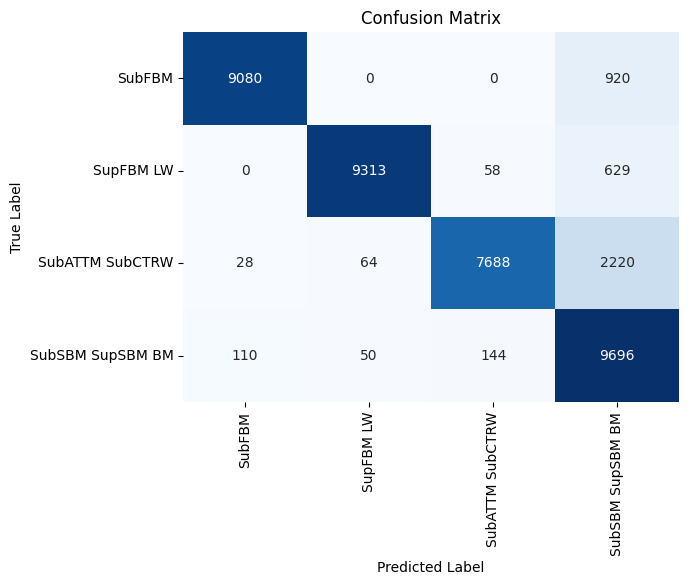

In [12]:
# make confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

heatmap_data = pd.DataFrame(
    confusion_matrix(ground_truth, predictions))

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["SubFBM", "SupFBM LW", "SubATTM SubCTRW", "SubSBM SupSBM BM"],
            yticklabels=["SubFBM", "SupFBM LW", "SubATTM SubCTRW", "SubSBM SupSBM BM"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# Calculate Grad-CAM for each split model

In [14]:
block=1
attr_path = f"./analysis_results/statistical_relevance_block/cutted_Grad-CAM/GradCAM-block{block}_{4}.npy"
attr_raw_path = f"./analysis_results/statistical_relevance_block/cutted_Grad-CAM/GradCAM-block{block}-raw_{4}.npy"
os.makedirs("./analysis_results/statistical_relevance_block/cutted_Grad-CAM", exist_ok=True)
if os.path.exists(attr_path) and os.path.exists(attr_raw_path):
    print("Grad-CAM for block1 already exists. Skipping computation.")
    attributions = np.load(attr_path, allow_pickle=True)
    attributions_raw = np.load(attr_raw_path, allow_pickle=True)
else:
    
    from captum.attr import LayerGradCam
    from captum.attr import LayerAttribution
    # get test dataset
    for i in range(train_dir_size):
        # load test dataset
        arr = np.load(f"./dataset_noiseless/test_1000/{i}.npy", allow_pickle=True)
        test_loader = prepare_dataloader(
            ds_tuple=(arr[0], arr[1]),
            batch_size=batch_size,
            balance=False,
            shuffle=False,
        label_map=label_map_dict,
        subset_ratio=1,
        )
        
        test_labels = test_loader.dataset.tensors[1].numpy()
        for lbl, cnt in Counter(test_labels).items():
            pct = cnt / len(test_labels) * 100
            print(f"Label {lbl}: {cnt} samples ({pct:.2f}%)")
        # print("Test dataset label ratio:")

        # Grad-CAM
        attributions = []
        attributions_raw = []
        sampled_dim = 1000
        cutted_model = cutted_model.to("cuda")

        with torch.no_grad():
            cutted_model.eval()
            for dataset in tqdm(test_loader):
                (X,y) = dataset
                inputs = X.to("cuda")
                target = y.to("cuda")

                gradcam = LayerGradCam(cutted_model, cutted_model[-4]) # cutted_model[4] is the last conv layer of block1
                attribution = gradcam.attribute(inputs=inputs, target=target)
                attribution = torch.squeeze(attribution, -2)
                attributions_raw.extend(torch.squeeze(attribution).tolist())
                attribution = LayerAttribution.interpolate(attribution, sampled_dim, interpolate_mode="nearest")
                attributions.extend(torch.squeeze(attribution).tolist())

        np.save(f"./analysis_results/statistical_relevance_block/cutted_Grad-CAM/GradCAM-block{block}_{i}", np.array(attributions))
        np.save(f"./analysis_results/statistical_relevance_block/cutted_Grad-CAM/GradCAM-block{block}-raw_{i}", np.array(attributions_raw))
        torch.cuda.empty_cache()


Grad-CAM for block1 already exists. Skipping computation.


In [15]:
# Redefine function for creating subtrajectories, then feature extraction and correlation calculation with Grad-CAM.

In [16]:
import numpy as np

def generate_stride_sequence(a, num_strides, total_length):
    """
    Generates a stride sequence (offsets) with some variability, aiming for symmetry,
    given a fixed value of 'a' and the number of strides.  The subtrajectories
    will have a length of 225 // a.

    Args:
        a (int): Determines the length of each sub-trajectory (length = 225 // a).
        num_strides (int): The desired number of strides (sub-trajectories) in the sequence.
        total_length (int): The desired total length of the trajectory.

    Returns:
        list: A list representing the stride sequence (offsets).
    """
    subtraj_length = 225 // a
    
    # Calculate the total length of all subtrajectories
    total_subtraj_length = subtraj_length * num_strides

    # Calculate the amount of overlap needed to achieve the desired total_length
    overlap_needed = total_subtraj_length - total_length

    if overlap_needed < 0:
        print("Warning:  Subtrajectories do not cover the full length.  Consider reducing num_strides.")
        overlap_needed = 0  # or handle the error as you see fit

    # Calculate the base overlap and remainder
    base_overlap = overlap_needed // (num_strides - 1) if num_strides > 1 else 0
    remainder = overlap_needed % (num_strides - 1) if num_strides > 1 else 0

    # Create the stride sequence (offsets)
    stride_sequence = []
    stride_sequence.append(0)
    for i in range(num_strides):
        if i < num_strides -1:
            stride = subtraj_length - base_overlap
            if i < remainder // 2:
                stride -= 1
            elif i >= num_strides - 1 - remainder // 2 and i < num_strides-1:
                stride -= 1
            stride_sequence.append(stride)

    return stride_sequence
# Example usage:
a_value = 8
num_strides_value = 250
total_length = 1000
stride_sequence = generate_stride_sequence(a_value, num_strides_value, total_length)

if stride_sequence:
    print(f"For a = {a_value}, num_strides = {num_strides_value}:")
    print(f"Stride Sequence: {stride_sequence}")
    print(f"Length: {225 // a_value}")
    print(f"Total Length: {225 // a_value + sum(stride_sequence)}")
else:
    print(f"No valid stride sequence found for a = {a_value}")

For a = 8, num_strides = 250:
Stride Sequence: [0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Length: 28
Total Length: 1000


In [ ]:
import torch

def array_split_stride_torch(trajs: torch.Tensor,
                             subtraj_length: int,
                             stride_sequence: list[int]
                            ) -> torch.Tensor:
    segs = [
        trajs[..., stride * i : stride * i + subtraj_length]
        for i, stride in enumerate(stride_sequence)
    ]
    return torch.stack(segs, dim=1)  # → (N, M, 2, subtraj_length)


In [18]:
def prepare_statistical_subtraj(
    ds_tuple: tuple,
    label_map: dict,
    denom: int = 8,
    num_strides_value: int = 250,
    ):
    """
    1) ds_tuple: (X_array, y_array)
    2) Scaling and dimension processing (_preprocessing_dataset)
    3) Batch decomposition (_get_dataloader)
    4) Label mapping → balancing → subset application
    """
    X, y = _preprocessing_dataset(ds_tuple, scale="minmax")
    stride_sequence = generate_stride_sequence(denom, num_strides_value, X.shape[-1])
    print("Stride sequence:", stride_sequence)
    print("Start splitting trajectories...")
    X = torch.from_numpy(X.astype(np.float32)).cuda()  # GPU로 변환
    X = array_split_stride_torch(X, subtraj_length=225 // denom, stride_sequence=stride_sequence)
    X = X.to('cpu', non_blocking=True).pin_memory().numpy()  # CPU로 옮기고, pin_memory
    print("Start mapping labels...")
    mapped = np.array([label_map[int(lbl.item())] for lbl in y])
    print("Done")
    return X, mapped


In [ ]:
import numpy as np
import torch
import time
from sklearn.preprocessing import MinMaxScaler

def manual_kurtosis_torch(x, nan=False):
    mean   = x.mean(dim=-1, keepdim=True)
    std    = x.std(dim=-1, keepdim=True, unbiased=False)
    fourth = ((x - mean)**4).mean(dim=-1)
    num = fourth 
    den = std.squeeze(-1)**4 
    kurt  = num / den - 3.0
    # if nan:
    #     return kurt
    # else:
    #     return torch.where(std.squeeze(-1)!=0, kurt, torch.zeros_like(kurt))
    kurt = torch.nan_to_num(kurt, nan=0.0)  # handle NaN values    
    return kurt


def mean_kurtosis_torch(diffs, nan=False):
    L = diffs.shape[-1]
    n_div = 4
    div = L / n_div
    segs = []
    for i in range(n_div):
        start, end = int(div*i), int(div*(i+1))
        seg = diffs[..., start:end]
        k   = manual_kurtosis_torch(seg, nan=nan)      # (B,M,2)
        segs.append(k.mean(dim=-1))           # (B,M)
    mean_k = torch.stack(segs, dim=0).mean(dim=0)  # (B,M)
    return mean_k

def jump_event_torch(diffs, nan=False):
    num   = torch.abs(diffs[..., 1:]  + 1e-6)                  # abs(diffs[1:]) + eps
    den   = torch.abs(diffs[..., :-1] + 1e-6)                  # abs(diffs[:-1] + eps)
    inc   = num / den                                          # exactly np code
    std_t = inc.std(dim=-1, unbiased=False)                       # ddof=0
    return std_t.max(dim=-1)[0]                                # max over channel


def autocorrelation_norm_torch(diffs, nan=False):
    # data is already double precision
    mean  = diffs.mean(dim=-1, keepdim=True)
    am    = diffs - mean
    num   = (am[..., :-1] * am[..., 1:]).sum(dim=-1)
    den   = torch.sqrt(
               (am[..., :-1]**2).sum(dim=-1) *
               (am[..., 1:]**2).sum(dim=-1)
            )
    if nan:
        ac = num/den
    else:
        ac    = torch.where(den != 0, num/den, torch.ones_like(num))
    return ac.mean(dim=-1)

def varying_diffusivity_torch(diffs, nan=False):
    L     = diffs.shape[-1]
    n_div = 4
    div   = L / n_div
    std0  = diffs[..., int(div*0):int(div*1)].std(dim=-1, unbiased=False)
    stdf  = diffs[..., int(div*(n_div-1)):int(div*n_div)].std(dim=-1, unbiased=False)
    num   = (-std0 + stdf).mean(dim=-1) / n_div
    den   = diffs.std(dim=-1, unbiased=False).mean(dim=-1)
    if nan:
        return num/den
    else:
        return torch.where(den!=0, num/den, torch.zeros_like(num))

def var_cos_angle_torch(diffs, nan=False):
    vx, vy = diffs[...,0,:], diffs[...,1,:]
    num  = vx[..., :-1]*vx[...,1:] + vy[..., :-1]*vy[...,1:]
    den  = torch.sqrt(
        (vx[..., :-1]**2 + vy[..., :-1]**2) *
        (vx[...,1:]**2 + vy[...,1:]**2)
    )
    ang  = torch.acos(torch.clamp(num/den, -1, 1)) / np.pi
    ang  = torch.nan_to_num(ang, nan=0.0)
    return ang.std(dim=-1, unbiased=False)



In [20]:

# get test dataset
i=0
for i in range(5):
    if os.path.exists(f"./analysis_results/statistical_relevance_block/feature_dict_block{block}_{i}.npy"):
        print(f"Feature dict for block{block}_{i} already exists. Skipping computation.")
        continue
    print(f"Processing file {i}...")
    arr = np.load(f"./dataset_noiseless/test_1000/{i}.npy", allow_pickle=True)
    X, y = prepare_statistical_subtraj(
        ds_tuple=(arr[0], arr[1]),
        label_map=label_map_dict,
        denom=1,
        num_strides_value=32,
    )

    feature_dict = {}

    print("Calculating statistical features...")

    torch_X = torch.from_numpy(X.astype(np.float64))
    torch_X = torch_X.diff(dim=-1)
    print("Calculating autocorrelation...")
    f1 = autocorrelation_norm_torch(torch_X).to('cpu', non_blocking=True).pin_memory().numpy()
    print("Calculating mean kurtosis...")
    f2 = mean_kurtosis_torch(torch_X).to('cpu', non_blocking=True).pin_memory().numpy()
    print("Calculating jump event...")
    f3 = jump_event_torch(torch_X).to('cpu', non_blocking=True).pin_memory().numpy()
    print("Calculating varying diffusivity...")
    f4 = varying_diffusivity_torch(torch_X).to('cpu', non_blocking=True).pin_memory().numpy()
    print("Calculating cosine angle variance...")
    f5 = var_cos_angle_torch(torch_X).to('cpu', non_blocking=True).pin_memory().numpy()

    f2 = np.abs(f2)
    f2 = MinMaxScaler().fit_transform(f2.T).T
    f3 = np.abs(f3)
    f3 = MinMaxScaler().fit_transform(f3.T).T
    f5 = np.abs(f5)
    f5 = MinMaxScaler().fit_transform(f5.T).T

    AC = f1
    CS = f1 * f5
    SG = f3 * f2
    VD = f4 * f2
    feature_dict['AC'] = AC
    feature_dict['CS'] = CS
    feature_dict['SG'] = SG
    feature_dict['VD'] = VD

    np.save(f"./analysis_results/statistical_relevance_block/feature_dict_block{block}_{i}.npy", feature_dict)

Feature dict for block1_0 already exists. Skipping computation.
Feature dict for block1_1 already exists. Skipping computation.
Feature dict for block1_2 already exists. Skipping computation.
Feature dict for block1_3 already exists. Skipping computation.
Feature dict for block1_4 already exists. Skipping computation.


In [21]:
statistical_relevance_dict = {}
statistical_relevance_dict["features"] = {}
statistical_relevance_dict["gradcam_raw"] = []
statistical_relevance_dict["features"]["AC"] = []
statistical_relevance_dict["features"]["CS"] = []
statistical_relevance_dict["features"]["SG"] = []
statistical_relevance_dict["features"]["VD"] = []
for i in tqdm(range(5)):
    feature_dict = np.load(f"./analysis_results/statistical_relevance_block/feature_dict_block{block}_{i}.npy", allow_pickle=True).item()
    attributions_raw = np.load(f"./analysis_results/statistical_relevance_block/cutted_Grad-CAM/GradCAM-block{block}-raw_{i}.npy", allow_pickle=True)
    print(feature_dict["AC"].shape, feature_dict["CS"].shape, feature_dict["SG"].shape, feature_dict["VD"].shape, attributions_raw.shape)
    statistical_relevance_dict["features"]["AC"].append(feature_dict["AC"])
    statistical_relevance_dict["features"]["CS"].append(feature_dict["CS"])
    statistical_relevance_dict["features"]["SG"].append(feature_dict["SG"])
    statistical_relevance_dict["features"]["VD"].append(feature_dict["VD"])
    statistical_relevance_dict["gradcam_raw"].append(attributions_raw)

# make single array
statistical_relevance_dict["features"]["AC"] = np.concatenate(statistical_relevance_dict["features"]["AC"], axis=0)
statistical_relevance_dict["features"]["CS"] = np.concatenate(statistical_relevance_dict["features"]["CS"], axis=0)
statistical_relevance_dict["features"]["SG"] = np.concatenate(statistical_relevance_dict["features"]["SG"], axis=0)
statistical_relevance_dict["features"]["VD"] = np.concatenate(statistical_relevance_dict["features"]["VD"], axis=0)
statistical_relevance_dict["gradcam_raw"] = np.concatenate(statistical_relevance_dict["gradcam_raw"], axis=0)
    

 20%|██        | 1/5 [00:00<00:00,  5.07it/s]

(80000, 32) (80000, 32) (80000, 32) (80000, 32) (80000, 32)


 60%|██████    | 3/5 [00:00<00:00,  4.91it/s]

(80000, 32) (80000, 32) (80000, 32) (80000, 32) (80000, 32)
(80000, 32) (80000, 32) (80000, 32) (80000, 32) (80000, 32)


 80%|████████  | 4/5 [00:00<00:00,  4.65it/s]

(80000, 32) (80000, 32) (80000, 32) (80000, 32) (80000, 32)


100%|██████████| 5/5 [00:01<00:00,  4.58it/s]

(80000, 32) (80000, 32) (80000, 32) (80000, 32) (80000, 32)


In [22]:
from scipy.stats import pearsonr, spearmanr

In [23]:
arr = np.load(f"./dataset_noiseless/test_1000/0.npy", allow_pickle=True)
ds_tuple = arr[0], arr[1]
X, y = _preprocessing_dataset(ds_tuple, scale="minmax")
y = np.array([label_map_dict[int(lbl.item())] for lbl in y])


In [24]:
label_indexes_list = [[],[],[],[]]
for j in range(5):
    label_indexes_list_current = [np.where(y == i)[0]+80000*j for i in range(4)]
    for k in range(4):
        label_indexes_list[k].extend(label_indexes_list_current[k].tolist())

In [25]:
tot_n1 = [[] for _ in range(4)]
tot_n2 = [[] for _ in range(4)]
tot_n3 = [[] for _ in range(4)]
tot_n4 = [[] for _ in range(4)]
tot_gc = [[] for _ in range(4)]
s1 = statistical_relevance_dict['features']['AC']
s2 = statistical_relevance_dict['features']['CS']
s3 = statistical_relevance_dict['features']['SG']
s4 = statistical_relevance_dict['features']['VD']
gc = np.array(statistical_relevance_dict['gradcam_raw'])

# label_indexes_list = [np.where(y == i)[0]*5 for i in range(4)]

pearson_table = {"label": [], "opts": [], "pearsonr": []}
label_list = ["SubFBM", "FBM/LW", "ATTM/CTRW", "SBM/BM"]

for label, label_indexes in enumerate(label_indexes_list):
    print(f"Label {label} has {len(label_indexes)} samples")
    concat_gc_raw = np.concatenate(gc[label_indexes], axis=0).flatten()
    
    for feat_idx, feat in enumerate([s1, s2, s3, s4]):
        concat_feat = np.concatenate(feat[label_indexes], axis=0).flatten()
        # consider only non-constant values
        index = (np.concatenate(s1[label_indexes], axis=0).flatten()!=1)
        # if feat_idx == 2:
        #     index = index & (concat_feat != 0)
        concat_gc = concat_gc_raw[index]
        concat_feat = concat_feat[index]
        # percentile filtering
        # p = 0.1
        # percentile_index = np.percentile(concat_feat, [p, 100-p])
        # concat_gc = concat_gc[(concat_feat > percentile_index[0]) & (concat_feat < percentile_index[1])]
        # concat_feat = concat_feat[(concat_feat > percentile_index[0]) & (concat_feat < percentile_index[1])]
        print(concat_gc.shape, concat_feat.shape)

        pearson_r = pearsonr(concat_gc, concat_feat)
        pearson_table["label"].append(label_list[label])
        pearson_table["opts"].append(feat_idx)
        pearson_table["pearsonr"].append(pearson_r[0])





Label 0 has 50000 samples
(1600000,) (1600000,)
(1600000,) (1600000,)
(1600000,) (1600000,)
(1600000,) (1600000,)
Label 1 has 100000 samples
(3200000,) (3200000,)
(3200000,) (3200000,)
(3200000,) (3200000,)
(3200000,) (3200000,)
Label 2 has 100000 samples
(2324345,) (2324345,)
(2324345,) (2324345,)
(2324345,) (2324345,)
(2324345,) (2324345,)
Label 3 has 150000 samples
(4800000,) (4800000,)
(4800000,) (4800000,)
(4800000,) (4800000,)
(4800000,) (4800000,)


In [26]:
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [27]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('physrev_noticks.mplstyle')
plt.rcParams.update({"figure.figsize": [3.25*1/2, 1.01]})
plt.rcParams['figure.dpi'] = "300"

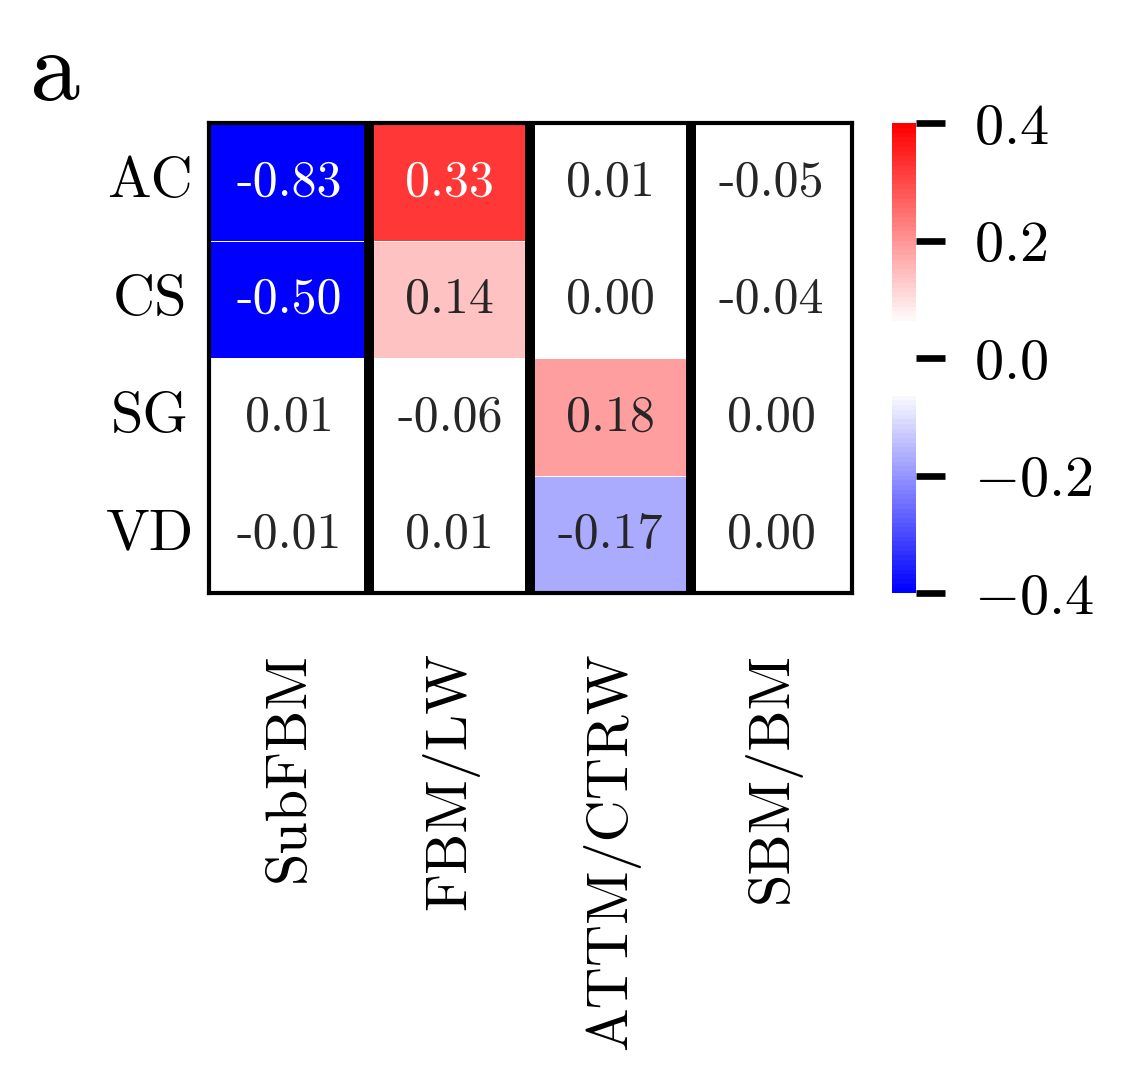

In [28]:
pd_pearson = pd.DataFrame(pearson_table)
heatmap_data = pd_pearson.pivot(columns='label', index='opts', values='pearsonr')
heatmap_data = heatmap_data[["SubFBM", 
                             "FBM/LW", "ATTM/CTRW", "SBM/BM"]]


# Define the colormap with a wide plateau around 0
colors = [(0, 0, 1), (1, 1, 1), ( 1, 1, 1), (1, 1, 1), (1, 0, 0)]  # Blue to Gray to White to Gray to Red
n_bins = 100  # Number of bins
cmap_name = "custom_cmap"
color_stops = [0.0, 0.85 / 2, 0.5, 1.15 / 2, 1.0]
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, list(zip(color_stops, colors)), N=n_bins)
norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)
    
ax = sns.heatmap(heatmap_data, annot=True, vmin=-0.4, vmax=0.4, cmap=custom_cmap, norm=norm, linewidths=0.1,
            linecolor='white', fmt='.2f', cbar=True, annot_kws={"size": 6})
ax.set_yticklabels(ax.get_yticklabels(), rotation="horizontal", horizontalalignment="center")
ax.set_yticklabels(["AC", "CS", "SG", "VD"])
for i in range(1, len(heatmap_data.columns)):
    if i in [4,6,7]:
        continue
    ax.axvline(i, color='black', linestyle='-', linewidth=1.2)
###########
# upper left supplot name, "a"
ax.text(-0.2, 1.2, 'a', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

ax.spines[["bottom", "top", "left", "right"]].set_visible(True)
plt.xlabel("")
plt.ylabel("")
plt.savefig("./figures/statistical_relevance_block1.pdf")
plt.show()